<h1 align="center" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">
<font color="#6E54C8">
Transformers in JAX &mdash; Part 4: Assembling and Training Mini-GPT at Quera
</font>
</h1>

<h3 align="left" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">
<font color="#6E54C8">
Part 1 &mdash; The Backstory
</font>
</h3>

<p dir="ltr" style="direction: ltr;text-align: justify;line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:medium">
<font size=3>
After three notebooks of building parts, Nika finally has every brick she needs, and tonight she assembles the wall. She is doing the final build on a shared machine the team rents through <b>Quera</b>, partly because it has more memory than her laptop and partly because Quera's automatic judge will later grade the students who follow her notebook. Assembling the model turns out to be almost anticlimactic, because a GPT is mostly embeddings followed by a stack of the transformer blocks she already wrote. What genuinely matters now is training, and training needs only three new ideas, namely a loss that measures how surprised the model is by the true next character, an optimizer that nudges the weights, and a single compiled step that does it fast. Borna had warned her that the previous toy model was too small to impress anyone, so this time she widens it to six layers and an embedding size of one hundred ninety two, roughly two and a half million parameters. She wraps the update in jax.jit, points it at the training data, and settles in to watch a number fall. For the first time in the project she has nothing to do but wait.
</font>
</p>

<div style="text-align:center;">
    <img src="images/quera.svg" style="width:40%;">
</div>

<h3 align="left" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">
<font color="#6E54C8">
Part 2 &mdash; The Mission Brief
</font>
</h3>

<p dir="ltr" style="direction: ltr;text-align: justify;line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:medium">
<font size=3>
The loss begins near four point two, exactly what a model that guesses uniformly among sixty five characters should produce, and then it slides downward in the jagged, hopeful way that loss curves do. Nika watches the validation loss as carefully as the training loss, because the gap between them is the early-warning sign of overfitting that dropout and weight decay are meant to fight. She also keeps an eye on the gradient norm, since a sudden spike there usually means the learning rate is too high and the model is about to destabilize. Every few hundred steps she samples a short passage, and the samples evolve from pure static, to static with the right rhythm, to fragments that contain real words like the and lord and even a plausible stage direction. By the time the schedule has cosine-decayed the learning rate toward zero, the bigger model is clearly sharper than the toy from her early experiments. She saves the loss curves for the demo and writes a one-line message to the team channel that simply says it is alive. Tomorrow she will teach it to speak on demand, which is the subject of the final notebook. For now, the wall stands, and it has learned to dream in English.
</font>
</p>

<div style="text-align:center;">
    <img src="images/quera1.png" style="width:100%;">
</div>

<div style="text-align:center;">
    <img src="images/transformer_architecture.png" width="300">
    <p style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:small;color:#666;margin-top:6px;"><i>We assemble the decoder (right-hand) column: embeddings, a stack of blocks, a final norm, and a linear head.</i></p>
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">Learning note &mdash; From blocks to a model: embeddings and the head</h4>
<p style="line-height:180%; font-size:medium;">
A GPT wraps the transformer blocks with three simple pieces. A <b>token embedding</b> (<code>nn.Embed(vocab_size, n_embd)</code>) is a lookup table that maps each token id to a learned vector. A <b>positional embedding</b> (<code>nn.Embed(block_size, n_embd)</code>) is a learned vector per position; GPT uses learned positions, in contrast to the fixed sinusoids you saw in Part 2. We add the two embeddings, run the sum through <code>n_layer</code> transformer blocks, apply a final LayerNorm, and project with a linear <b>head</b> (<code>nn.Dense(vocab_size)</code>) to produce <b>logits</b> of shape <code>(batch, time, vocab)</code>. Logit (b, t, :) scores every possible character that could follow position t in sequence b.
</p>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">Learning note &mdash; Cross-entropy: the next-token loss</h4>
<p style="line-height:180%; font-size:medium;">
Next-token prediction is a classification problem over the vocabulary, so the natural loss is the mean <b>cross-entropy</b> between the predicted distribution and the true next token. optax provides a numerically stable version, <code>optax.softmax_cross_entropy_with_integer_labels</code>, that takes raw logits and integer targets directly. At initialization the model knows nothing, so it spreads probability roughly uniformly over the vocabulary, and the loss should sit near the natural logarithm of the vocabulary size, which for sixty five characters is about 4.17. Watching the loss start there and fall is the simplest sanity check that training is working.
</p>
<div style="text-align:center;">
    <img src="images/gpt_logo.svg" style="width:40%;">
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">Learning note &mdash; AdamW, gradient clipping, and a warmup-cosine schedule</h4>
<p style="line-height:180%; font-size:medium;">
We optimize with <b>AdamW</b>, the Adam optimizer with decoupled weight decay, which is the standard choice for transformers. We precede it with <b>global-norm gradient clipping</b> so that an occasional huge gradient cannot blow up the weights. We also vary the learning rate over time rather than keeping it fixed: a short <b>warmup</b> ramps it up from zero so the random initial weights are not wrecked by the first noisy gradients, and a <b>cosine decay</b> afterwards lets the model settle as it converges. In JAX this is expressed cleanly by composing transformations with <code>optax.chain</code> and passing a schedule function as the learning rate.
</p>
<div style="text-align:center;">
    <img src="images/jax_logo.png" style="width:40%;">
</div>

In [1]:
import os, time, math, pickle, urllib.request
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)

print("JAX", jax.__version__, "| Flax", nn.__version__ if hasattr(nn,"__version__") else "", "| devices:", jax.devices())

JAX 0.7.2 | Flax  | devices: [CudaDevice(id=0), CudaDevice(id=1)]


<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">Learning note &mdash; Continuing from Part 3</h4>
<p style="line-height:180%; font-size:medium;">
This part sits in the middle of a continuous chain. The cell below brings forward, unchanged, exactly the <code>CausalSelfAttention</code> and <code>TransformerBlock</code> you implemented in Part 3 (Tapsi), together with the tokenizer and batching from Part 1 (Snapp). Nothing here is re-derived; we simply stack those blocks into the full MiniGPT and train it, and the trained weights are saved at the end so that Part 5 (Divar) can load them and generate text.
</p>
<div style="text-align:center;">
    <img src="images/quera2.png" style="width:100%;">
</div>

In [2]:
# Setup (given) — solved code from Parts 1-3 (data, tokenizer, batcher, modules).

def load_tiny_shakespeare():
    for path in ("data/tiny_shakespeare.txt", "tiny_shakespeare.txt", "../data/tiny_shakespeare.txt"):
        if os.path.exists(path):
            return open(path, encoding="utf-8").read()
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(url, "data/tiny_shakespeare.txt")
    return open("data/tiny_shakespeare.txt", encoding="utf-8").read()

text = load_tiny_shakespeare()
print(f"Corpus length: {len(text):,} characters")

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join(itos[int(i)] for i in ids)

data = np.array(encode(text), dtype=np.int32)

n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"train: {len(train_data):,} tokens | val: {len(val_data):,} tokens")

def get_batch(key, split, batch_size, block_size):
    source = train_data if split == "train" else val_data
    ix = jax.random.randint(key, (batch_size,), 0, len(source) - block_size - 1)
    ix = np.asarray(ix)
    x = np.stack([source[i:i + block_size] for i in ix])
    y = np.stack([source[i + 1:i + 1 + block_size] for i in ix])
    return jnp.asarray(x), jnp.asarray(y)

class CausalSelfAttention(nn.Module):
    n_head: int
    n_embd: int
    dropout: float = 0.0

    @nn.compact
    def __call__(self, x, deterministic=True):
        B, T, C = x.shape
        d_head = C // self.n_head
        qkv = nn.Dense(3 * C, use_bias=False, name="qkv")(x)
        q, k, v = jnp.split(qkv, 3, axis=-1)

        def split_heads(t):
            return t.reshape(B, T, self.n_head, d_head).transpose(0, 2, 1, 3)
        q, k, v = split_heads(q), split_heads(k), split_heads(v)

        scores = (q @ jnp.swapaxes(k, -1, -2)) / jnp.sqrt(d_head)
        mask = jnp.tril(jnp.ones((T, T), dtype=bool))
        scores = jnp.where(mask, scores, -1e9)
        attn = jax.nn.softmax(scores, axis=-1)
        attn = nn.Dropout(self.dropout)(attn, deterministic=deterministic)

        out = attn @ v
        out = out.transpose(0, 2, 1, 3).reshape(B, T, C)
        out = nn.Dense(C, name="proj")(out)
        out = nn.Dropout(self.dropout)(out, deterministic=deterministic)
        return out

class TransformerBlock(nn.Module):
    n_head: int
    n_embd: int
    dropout: float = 0.0

    @nn.compact
    def __call__(self, x, deterministic=True):
        x = x + CausalSelfAttention(self.n_head, self.n_embd, self.dropout)(
            nn.LayerNorm()(x), deterministic)
        h = nn.LayerNorm()(x)
        h = nn.Dense(4 * self.n_embd)(h)
        h = nn.gelu(h)
        h = nn.Dense(self.n_embd)(h)
        h = nn.Dropout(self.dropout)(h, deterministic=deterministic)
        return x + h

print('recap ready: data + CausalSelfAttention + TransformerBlock')

Corpus length: 1,115,394 characters
train: 1,003,854 tokens | val: 111,540 tokens
recap ready: data + CausalSelfAttention + TransformerBlock


<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">1. Assemble the MiniGPT module</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Implement the model. With <code>B, T = idx.shape</code>: build the token embedding with <code>nn.Embed(self.vocab_size, self.n_embd, name="tok_emb")(idx)</code>; the positional embedding with <code>nn.Embed(self.block_size, self.n_embd, name="pos_emb")(jnp.arange(T))</code>; add them (broadcasting the positions over the batch) and apply dropout; loop <code>self.n_layer</code> times applying <code>TransformerBlock(self.n_head, self.n_embd, self.dropout, name=f"block_{i}")</code>; finish with <code>nn.LayerNorm()</code> and a <code>nn.Dense(self.vocab_size, name="head")</code> to produce the logits.
</p>
</p>

In [3]:
class MiniGPT(nn.Module):
    vocab_size: int
    block_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0

    @nn.compact
    def __call__(self, idx, deterministic=True):
        B, T = idx.shape
        
        # Build token and positional embeddings
        tok = nn.Embed(self.vocab_size, self.n_embd, name="tok_emb")(idx)
        pos = nn.Embed(self.block_size, self.n_embd, name="pos_emb")(jnp.arange(T))
        
        # Add embeddings together and apply dropout
        x = tok + pos[None, :, :]
        x = nn.Dropout(self.dropout)(x, deterministic=deterministic)
        
        # Apply self.n_layer TransformerBlock layers sequentially
        for i in range(self.n_layer):
            x = TransformerBlock(
                n_head=self.n_head, 
                n_embd=self.n_embd, 
                dropout=self.dropout, 
                name=f"block_{i}"
            )(x, deterministic=deterministic)
            
        # Apply final LayerNorm and the linear head to produce logits
        x = nn.LayerNorm()(x)
        logits = nn.Dense(self.vocab_size, name="head")(x)
        
        return logits

OK: MiniGPT logits shape (8, 64, 65)
total parameters: 2,703,425


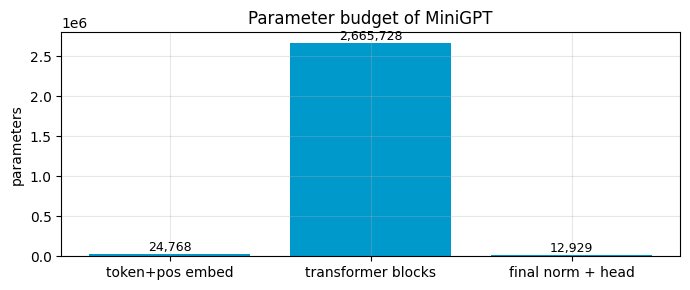

In [4]:
# The bigger configuration for this notebook (~2.7M parameters).
cfg = dict(vocab_size=vocab_size, block_size=64, n_layer=6, n_head=6, n_embd=192, dropout=0.1)
model = MiniGPT(**cfg)
params = model.init(jax.random.PRNGKey(1337), jnp.zeros((1, cfg["block_size"]), jnp.int32))
n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))

xb, yb = get_batch(jax.random.PRNGKey(0), "train", 8, cfg["block_size"])
logits = model.apply(params, xb)
assert logits.shape == (8, cfg["block_size"], vocab_size)
print("OK: MiniGPT logits shape", logits.shape)
print(f"total parameters: {n_params:,}")

# Chart: where do the parameters live?
def count(t): return int(sum(p.size for p in jax.tree_util.tree_leaves(t)))
p = params["params"]
parts = {"token+pos embed": count(p["tok_emb"]) + count(p["pos_emb"]),
         "transformer blocks": sum(count(p[k]) for k in p if k.startswith("block_")),
         "final norm + head": count(p["LayerNorm_0"]) + count(p["head"])}
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(parts.keys(), parts.values(), color="#0099cc")
for i, v in enumerate(parts.values()): ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set_title("Parameter budget of MiniGPT"); ax.set_ylabel("parameters")
plt.tight_layout(); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">2. The cross-entropy loss</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Implement <code>compute_loss</code>. Run the model with dropout ON (training mode) by passing <code>deterministic=False</code> and an rng via <code>rngs={"dropout": dropout_key}</code>, then return the mean of <code>optax.softmax_cross_entropy_with_integer_labels(logits, y)</code>.
</p>
</p>

In [5]:
def compute_loss(params, x, y, dropout_key):
    # Forward pass with dropout ON (deterministic=False)
    logits = model.apply(params, x, deterministic=False, rngs={"dropout": dropout_key})
    
    # Compute the mean cross-entropy loss using the integer labels
    return optax.softmax_cross_entropy_with_integer_labels(logits, y).mean()

In [6]:
init_loss = compute_loss(params, xb, yb, jax.random.PRNGKey(0))
print(f"initial loss = {float(init_loss):.3f}   |   ln(vocab) = {math.log(vocab_size):.3f}")
assert abs(float(init_loss) - math.log(vocab_size)) < 1.0
print("OK: untrained loss is near ln(vocab), as expected")

initial loss = 4.828   |   ln(vocab) = 4.174
OK: untrained loss is near ln(vocab), as expected


<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">3. The warmup-cosine learning-rate schedule</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Implement <code>make_lr_schedule</code> returning <code>optax.warmup_cosine_decay_schedule(init_value=0.0, peak_value=peak_lr, warmup_steps=warmup_steps, decay_steps=total_steps, end_value=peak_lr * 0.1)</code>.
</p>
</p>

In [7]:
def make_lr_schedule(peak_lr, warmup_steps, total_steps):
    # Create a warmup cosine decay schedule based on the specified parameters
    return optax.warmup_cosine_decay_schedule(
        init_value=0.0, 
        peak_value=peak_lr, 
        warmup_steps=warmup_steps, 
        decay_steps=total_steps, 
        end_value=peak_lr * 0.1
    )

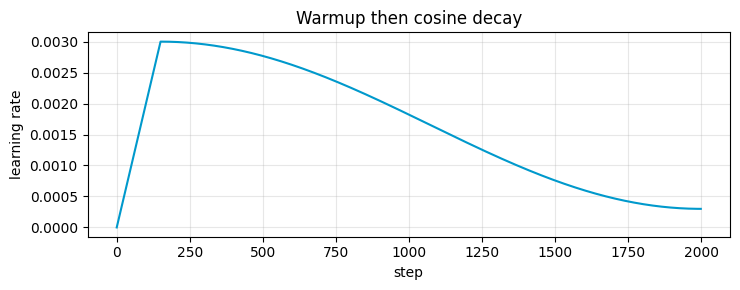

OK: schedule warms up then decays


In [8]:
batch_size, max_steps, warmup_steps, peak_lr = 32, 2000, 150, 3e-3
schedule = make_lr_schedule(peak_lr, warmup_steps, max_steps)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=schedule, weight_decay=0.1, b1=0.9, b2=0.99),
)
lrs = [float(schedule(s)) for s in range(max_steps)]
fig, ax = plt.subplots(figsize=(7.5, 3))
ax.plot(lrs, color="#0099cc"); ax.set_xlabel("step"); ax.set_ylabel("learning rate")
ax.set_title("Warmup then cosine decay"); plt.tight_layout(); plt.show()
assert lrs[0] < lrs[warmup_steps] and lrs[-1] < lrs[warmup_steps]
print("OK: schedule warms up then decays")

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">4. The JIT-compiled training step</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Implement and JIT-compile one optimization step: compute loss and gradients with <code>jax.value_and_grad(compute_loss)(params, x, y, dropout_key)</code>, get updates with <code>optimizer.update(grads, opt_state, params)</code>, apply them with <code>optax.apply_updates</code>, and return <code>params, opt_state, loss</code>.
</p>
</p>

In [9]:
@jax.jit
def train_step(params, opt_state, x, y, dropout_key):
    # Compute the loss and the gradients simultaneously
    loss, grads = jax.value_and_grad(compute_loss)(params, x, y, dropout_key)
    
    # Calculate the optimizer updates and the new optimizer state
    updates, opt_state = optimizer.update(grads, opt_state, params)
    
    # Apply the computed updates to the model parameters
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss

In [10]:
# eval loss = forward with dropout off (given)
@jax.jit
def eval_loss(params, x, y):
    logits = model.apply(params, x, deterministic=True)
    return optax.softmax_cross_entropy_with_integer_labels(logits, y).mean()

# quick check: a few steps on one fixed batch must reduce the loss
_p = model.init(jax.random.PRNGKey(0), jnp.zeros((1, cfg["block_size"]), jnp.int32))
_os = optimizer.init(_p)
before = float(eval_loss(_p, xb, yb))
for i in range(20):
    _p, _os, _ = train_step(_p, _os, xb, yb, jax.random.PRNGKey(i))
print(f"loss on a fixed batch: {before:.3f} -> {float(eval_loss(_p, xb, yb)):.3f}")
assert float(eval_loss(_p, xb, yb)) < before
print("OK: train_step learns")

loss on a fixed batch: 4.569 -> 2.749
OK: train_step learns


<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">5. Train the model</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
We re-initialize fresh parameters and run the training loop. Every 250 steps we record the validation loss and the gradient norm, and print a short sample so we can watch the model improve. On a CPU this takes several minutes; it is the longest cell in the lab.
</p>
</p>
<div style="text-align:center;">
    <img src="images/quera4.png" style="width:40%;">
</div>

In [11]:
def sample(params, key, prompt="ROMEO:", n_new=240, temperature=0.8):
    idx = jnp.array([encode(prompt)], dtype=jnp.int32)
    for _ in range(n_new):
        logits = model.apply(params, idx[:, -cfg["block_size"]:], deterministic=True)[:, -1, :] / temperature
        key, sk = jax.random.split(key)
        idx = jnp.concatenate([idx, jax.random.categorical(sk, logits, axis=-1)[:, None]], axis=1)
    return decode(idx[0])

params = model.init(jax.random.PRNGKey(1337), jnp.zeros((1, cfg["block_size"]), jnp.int32))
opt_state = optimizer.init(params)
key = jax.random.PRNGKey(0)
hist_steps, hist_train, hist_val, hist_gnorm = [], [], [], []
t0 = time.time()
for step in range(max_steps + 1):
    key, bkey, dkey = jax.random.split(key, 3)
    xb, yb = get_batch(bkey, "train", batch_size, cfg["block_size"])
    params, opt_state, loss = train_step(params, opt_state, xb, yb, dkey)
    if step % 250 == 0:
        vx, vy = get_batch(jax.random.PRNGKey(step), "val", 64, cfg["block_size"])
        gnorm = optax.global_norm(jax.grad(compute_loss)(params, xb, yb, dkey))
        hist_steps.append(step); hist_train.append(float(loss))
        hist_val.append(float(eval_loss(params, vx, vy))); hist_gnorm.append(float(gnorm))
        print(f"step {step:>4} | train {float(loss):.3f} | val {hist_val[-1]:.3f} | "
              f"grad-norm {float(gnorm):.2f} | {time.time()-t0:5.1f}s")
print("\n--- sample after training ---\n" + sample(params, jax.random.PRNGKey(7)))

step    0 | train 4.737 | val 4.693 | grad-norm 7.22 |  26.1s
step  250 | train 2.192 | val 2.183 | grad-norm 0.43 |  31.5s
step  500 | train 1.947 | val 1.995 | grad-norm 0.44 |  37.0s
step  750 | train 1.776 | val 1.820 | grad-norm 0.34 |  42.4s
step 1000 | train 1.718 | val 1.777 | grad-norm 0.32 |  47.9s
step 1250 | train 1.573 | val 1.720 | grad-norm 0.30 |  53.4s
step 1500 | train 1.487 | val 1.568 | grad-norm 0.32 |  58.9s
step 1750 | train 1.479 | val 1.627 | grad-norm 0.33 |  64.5s
step 2000 | train 1.477 | val 1.565 | grad-norm 0.35 |  70.2s

--- sample after training ---
ROMEO:
'Tis not; but and she matter!
Put how conder you shall shall be reason more.

THOMAS MOWBRAY:
My lord, and I am good friends, how of his own,
Which you should not never to in my honour.

ESCALUS:
As I lay your life, in too there's I have y


<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">6. Diagnostics: loss curves, gradient norm, and weights</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Three charts summarize the run. The loss curves should fall and stay close to each other; a widening gap would signal overfitting. The gradient-norm curve should stay bounded thanks to clipping. The histogram of the trained weights should look like a tight, roughly bell-shaped distribution.
</p>
</p>
<div style="text-align:center;">
    <img src="images/quera5.png" style="width:40%;">
</div>

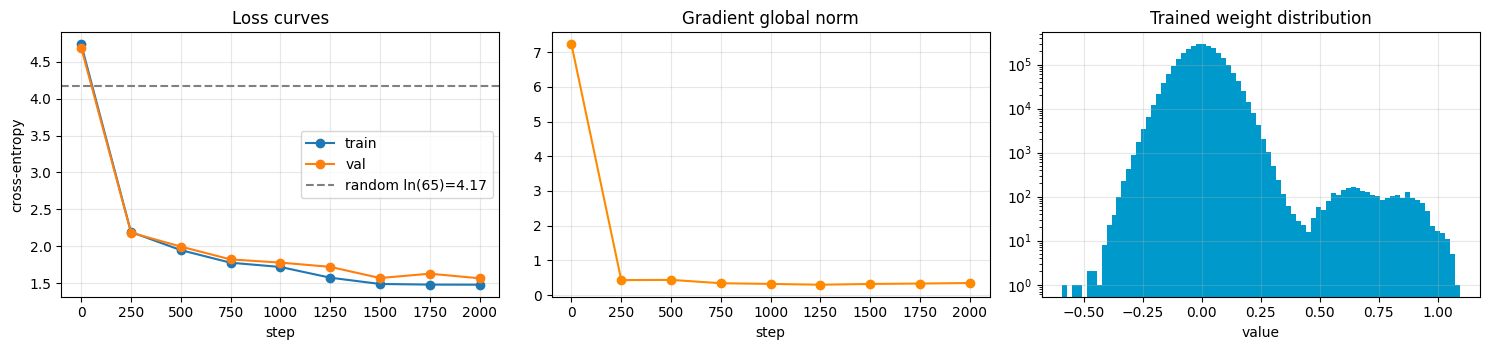

final train 1.477 | final val 1.565 | params 2,703,425


In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].plot(hist_steps, hist_train, "-o", label="train")
ax[0].plot(hist_steps, hist_val, "-o", label="val")
ax[0].axhline(math.log(vocab_size), ls="--", color="gray", label=f"random ln(65)={math.log(vocab_size):.2f}")
ax[0].set_title("Loss curves"); ax[0].set_xlabel("step"); ax[0].set_ylabel("cross-entropy"); ax[0].legend()
ax[1].plot(hist_steps, hist_gnorm, "-o", color="#ff8a00")
ax[1].set_title("Gradient global norm"); ax[1].set_xlabel("step")
flat = np.concatenate([np.asarray(p).ravel() for p in jax.tree_util.tree_leaves(params)])
ax[2].hist(flat, bins=80, color="#0099cc"); ax[2].set_yscale("log")
ax[2].set_title("Trained weight distribution"); ax[2].set_xlabel("value")
plt.tight_layout(); plt.show()
print(f"final train {hist_train[-1]:.3f} | final val {hist_val[-1]:.3f} | params {n_params:,}")

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">7. What did the trained model learn? Attention and embeddings</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Two final diagnostics look inside the trained network. First we plot the attention weights of the first transformer block on a real prompt; each head has specialized on a different pattern, which is the multi-head idea paying off. Then we project the learned token embeddings to two dimensions with PCA and discover that the model has organized characters into meaningful groups such as vowels, consonants, and punctuation, purely from the next-character objective.
</p>
</p>

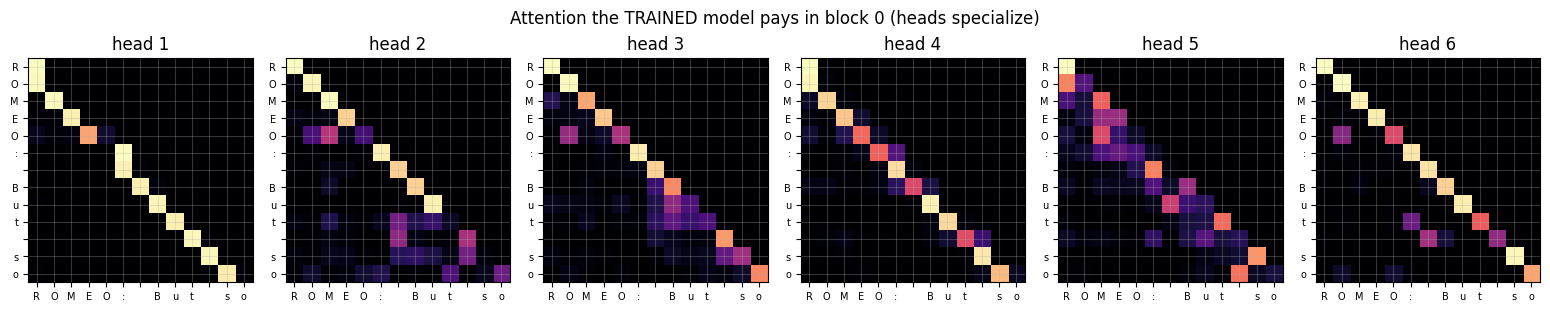

In [13]:
# Attention learned by block 0 of the TRAINED model on a real prompt.
sample_str = "ROMEO: But so"
ids = jnp.array(encode(sample_str)); T = len(ids)
P = params["params"]
x = P["tok_emb"]["embedding"][ids] + P["pos_emb"]["embedding"][:T]
lnp = P["block_0"]["LayerNorm_0"]
xn = lnp["scale"] * (x - x.mean(-1, keepdims=True)) / jnp.sqrt(x.var(-1, keepdims=True) + 1e-6) + lnp["bias"]
q, k, _ = jnp.split(xn @ P["block_0"]["CausalSelfAttention_0"]["qkv"]["kernel"], 3, axis=-1)
nh, dh = cfg["n_head"], cfg["n_embd"] // cfg["n_head"]
sh = lambda t: t.reshape(T, nh, dh).transpose(1, 0, 2)
q, k = sh(q), sh(k)
sc = (q @ jnp.swapaxes(k, -1, -2)) / jnp.sqrt(dh)
sc = jnp.where(jnp.tril(jnp.ones((T, T), bool)), sc, -1e9)
attn = jax.nn.softmax(sc, axis=-1)
fig, axes = plt.subplots(1, nh, figsize=(2.6 * nh, 3))
for h, ax in enumerate(axes):
    ax.imshow(np.array(attn[h]), cmap="magma")
    ax.set_title(f"head {h+1}")
    ax.set_xticks(range(T)); ax.set_xticklabels(list(sample_str), fontsize=7)
    ax.set_yticks(range(T)); ax.set_yticklabels(list(sample_str), fontsize=7)
fig.suptitle("Attention the TRAINED model pays in block 0 (heads specialize)")
plt.tight_layout(); plt.show()

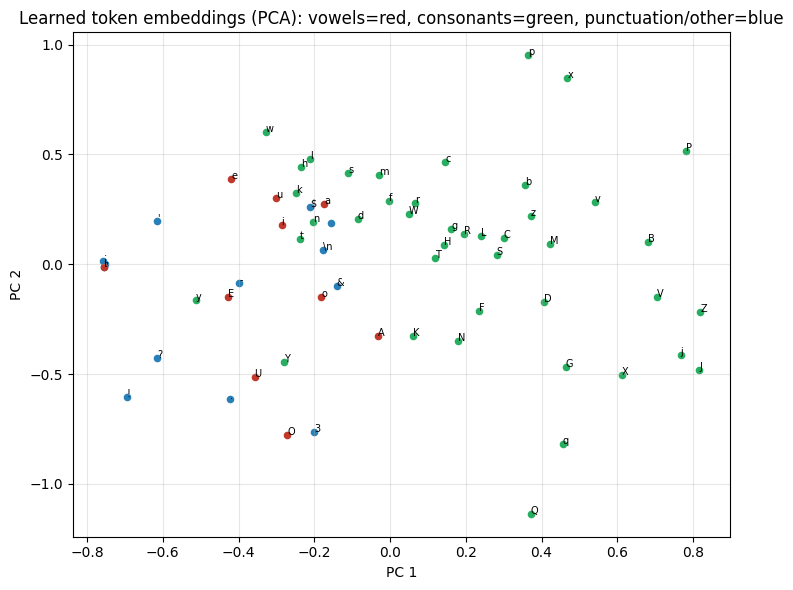

In [14]:
# What structure did the token embeddings learn? Project to 2D with PCA (via SVD).
emb = np.asarray(params["params"]["tok_emb"]["embedding"])
embc = emb - emb.mean(0)
_, _, Vt = np.linalg.svd(embc, full_matrices=False)
proj = embc @ Vt[:2].T
vowels = set("aeiouAEIOU")
fig, ax = plt.subplots(figsize=(7.5, 6))
for i in range(vocab_size):
    ch = itos[i]
    color = "#c0392b" if ch in vowels else ("#27ae60" if ch.isalpha() else "#2980b9")
    ax.scatter(proj[i, 0], proj[i, 1], color=color, s=20)
    ax.annotate(repr(ch)[1:-1], (proj[i, 0], proj[i, 1]), fontsize=7)
ax.set_title("Learned token embeddings (PCA): vowels=red, consonants=green, punctuation/other=blue")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
plt.tight_layout(); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#6E54C8">8. Save the trained model for Part 5</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
This trained model is the result the final notebook depends on, so we save it to disk. We pickle the parameters together with the configuration, the tokenizer maps, and the loss history into <code>minigpt_ckpt.pkl</code>. In Part 5 (Divar) you load this exact file and make the model generate text, which closes the continuous chain of the lab: the characters tokenized in Part 1 became the attention of Parts 2 and 3, which became the model trained here, which becomes the text generated in Part 5.
</p>
</p>

In [15]:
import pickle
ckpt = {
    "params": jax.tree_util.tree_map(np.asarray, params),
    "config": cfg,
    "stoi": stoi, "itos": itos,
    "history": {"steps": hist_steps, "train": hist_train, "val": hist_val},
}
with open("minigpt_ckpt.pkl", "wb") as f:
    pickle.dump(ckpt, f)
print(f"saved trained MiniGPT -> minigpt_ckpt.pkl  ({n_params:,} params)")
print("Part 5 (Divar) will load this file and generate text from it.")

saved trained MiniGPT -> minigpt_ckpt.pkl  (2,703,425 params)
Part 5 (Divar) will load this file and generate text from it.
